
# Assignment: Shadow-Invariant Vision with OpenCV and Kornia

## Motivation

A shadow can create a strong image boundary even though there is no corresponding boundary in scene geometry or material.

Before beginning, watch [a Tesla on FSD 14.2.2.5 swerve for a shadow](https://x.com/EliasMartinez/status/2034946481744929113), reported by Elias Martinez in March 2026. The driver disengaged.

The central question of this assignment is:

> Can we construct an image representation that responds strongly to changes in surface reflectance but weakly to changes caused only by illumination?

You will implement a shadow-invariant representation inspired by Chapter 10 of Peter Corke's *Robotics, Vision & Control*.

[Download Chapter 10, Light and Color (PDF, 40 pages)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)

Reference notebook:

https://github.com/petercorke/RVC3-python/blob/main/notebooks/chap10.ipynb

Focus on:

- §10.1 Spectral Representation of Light
- §10.2 Color
- §10.4 Application: Color Images
- §10.4.2 Shadow Removal

You will first implement the relevant computations with NumPy and OpenCV, then port the final shadow-invariant pipeline to PyTorch/Kornia.



## Learning Objectives

By the end of this assignment, you should be able to:

1. Explain why shadows alter image measurements without altering surface material.
2. Relate illumination spectra to measured color.
3. Compare RGB, HSV, and Lab for illuminated and shadowed regions.
4. Construct a log-chromaticity representation.
5. Compute a one-dimensional shadow-invariant image.
6. Quantitatively evaluate shadow suppression.
7. Port the final computation to a PyTorch/Kornia tensor pipeline.



# 1. Development Environment

Use the course development environment:

https://github.com/pantelis/eng-ai-agents

Open the repository in VS Code as a Dev Container.

Inside the container run:

```bash
make start
make install-notebooks
source .venv/bin/activate
```

`make start` alone installs only the base dependencies. `make install-notebooks` adds OpenCV, PyTorch and Kornia, which the sections below use.

GPU acceleration is not required for full credit.


In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import kornia
import time

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Kornia:", kornia.__version__)
print("CUDA available:", torch.cuda.is_available())


/workspaces/eng-ai-agents/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


OpenCV: 5.0.0
NumPy: 2.2.6
PyTorch: 2.14.0+cu130
Kornia: 0.8.3
CUDA available: True



# 2. Why Does a Shadow Change an Image?

A simplified image-formation model is

$$
I_k =
\int E(\lambda)R(\lambda)Q_k(\lambda)\,d\lambda,
$$

where

- $E(\lambda)$ is illumination,
- $R(\lambda)$ is surface reflectance,
- $Q_k(\lambda)$ is the spectral response of camera channel $k$.

The key observation is:

$$
\text{measured pixel value} \neq \text{surface reflectance alone}.
$$

Measured RGB depends on both the material and the illumination.

In a cast shadow, the material reflectance is approximately unchanged, but the illumination reaching the surface changes.



## 2.1 Blackbody Illumination

Implement Planck's law:

$$
B(\lambda,T)
=
\frac{2hc^2}{\lambda^5}
\frac{1}
{\exp\left(\frac{hc}{\lambda k_BT}\right)-1}.
$$

Plot normalized spectra for:

$$
T_1 = 2600\text{ K},
\qquad
T_2 = 5778\text{ K}.
$$

Answer briefly:

1. Why can the same material produce different RGB values under these two illuminants?
2. In a cast shadow, what changes: reflectance or illumination?


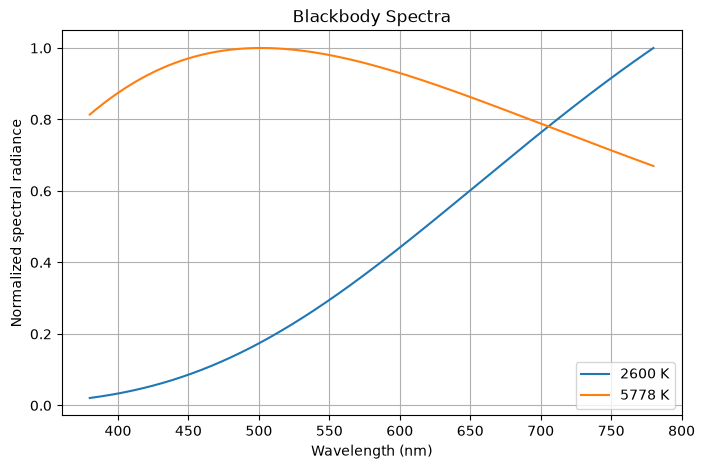

In [3]:

def blackbody(wavelength_m, temperature_k):
    h = 6.62607015e-34
    c = 299792458.0
    k_B = 1.380649e-23

    numerator = 2 * h * c**2

    denominator = (
        wavelength_m**5
        * (np.exp(h * c / (wavelength_m * k_B * temperature_k)) - 1)
    )

    return numerator / denominator

wavelength_nm = np.linspace(380, 780, 400)
wavelength_m = wavelength_nm * 1e-9

lamp = blackbody(wavelength_m, 2600)
sun = blackbody(wavelength_m, 5778)

lamp_norm = lamp / lamp.max()
sun_norm = sun / sun.max()

plt.figure(figsize=(8, 5))

plt.plot(wavelength_nm, lamp_norm, label="2600 K")
plt.plot(wavelength_nm, sun_norm, label="5778 K")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized spectral radiance")
plt.title("Blackbody Spectra")
plt.legend()
plt.grid()

plt.show()
# TODO:
# lamp = blackbody(wavelength_m, 2600)
# sun = blackbody(wavelength_m, 5778)
# Normalize each curve and plot both.



### Short Answer

Write your response here.

- Same material, different illuminants:The same material can have different RGB values because RGB depends on both material reflectance and illumination. Different light sources have different spectra, which changes the measured RGB values.
- What changes in a cast shadow:A cast shadow mainly changes the illumination, while the material reflectance remains approximately unchanged.



# 3. Observe a Shadow in Different Color Spaces

Use Corke's `parks.png` image or another supplied outdoor image containing a strong cast shadow.

Load the image with OpenCV and select two small regions of the same physical surface:

- one directly illuminated,
- one inside the shadow.

You will compare the regions in RGB, HSV, and Lab.


Image shape (H, W, C): (2448, 3264, 3)


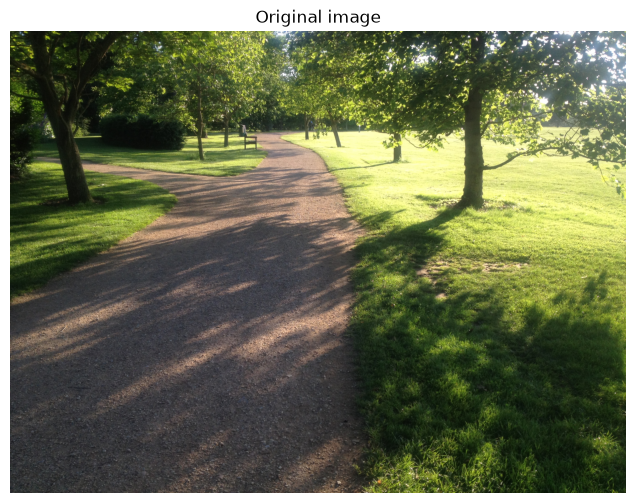

In [4]:

import os
import urllib.request

# parks.png is the outdoor scene Corke uses in chapter 10. It ships with the
# Machine Vision Toolbox data package (Peter Corke, MIT license).
IMAGE_URL = (
    "https://raw.githubusercontent.com/petercorke/machinevision-toolbox-python/"
    "main/packages/mvtb-data/mvtbdata/images/parks.png"
)
IMAGE_PATH = "parks.png"  # TODO: point this at your own image if you prefer

if not os.path.exists(IMAGE_PATH):
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(
        f"Could not load {IMAGE_PATH}. Check the path, or download the image "
        f"yourself from {IMAGE_URL}."
    )

print("Image shape (H, W, C):", image_bgr.shape)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()



## 3.1 Define Illuminated and Shadowed Regions

Choose two rectangular regions containing the same material.

Store them as:

```python
(x1, y1, x2, y2)
```

where `(x1, y1)` is the upper-left corner and `(x2, y2)` is the lower-right corner.


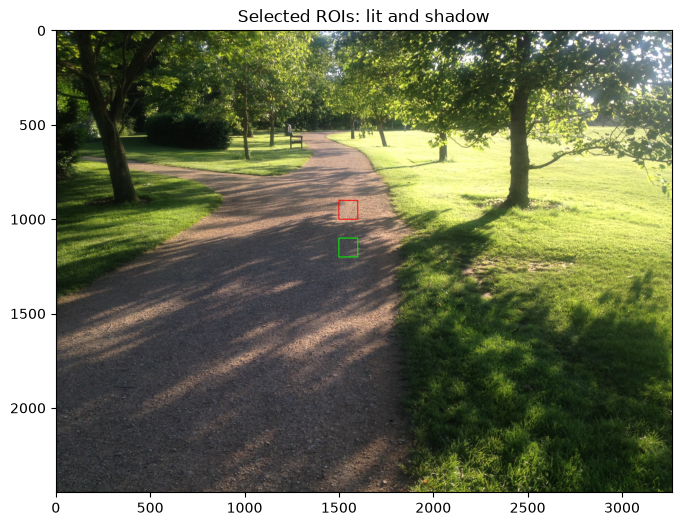

In [5]:

# TODO: replace with coordinates appropriate for your image.
lit_roi = (1500, 900, 1600, 1000)
shadow_roi = (1500, 1100, 1600, 1200)

display_img = image_rgb.copy()

x1, y1, x2, y2 = lit_roi
cv2.rectangle(display_img, (x1, y1), (x2, y2), (255, 0, 0), 3)

x1, y1, x2, y2 = shadow_roi
cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(10, 6))
plt.imshow(display_img)

plt.title("Selected ROIs: lit and shadow")
plt.show()

def crop_roi(image, roi):
    x1, y1, x2, y2 = roi
    return image[y1:y2, x1:x2]

def mean_color(image, roi):
    patch = crop_roi(image, roi)
    return patch.reshape(-1, patch.shape[-1]).mean(axis=0)

# TODO: visualize the chosen rectangles on the image.


In [6]:

hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

rgb_lit = mean_color(image_rgb, lit_roi)
rgb_shadow = mean_color(image_rgb, shadow_roi)

hsv_lit = mean_color(hsv, lit_roi)
hsv_shadow = mean_color(hsv, shadow_roi)

lab_lit = mean_color(lab, lit_roi)
lab_shadow = mean_color(lab, shadow_roi)

print("RGB lit:    ", rgb_lit)
print("RGB shadow: ", rgb_shadow)
print("HSV lit:    ", hsv_lit)
print("HSV shadow: ", hsv_shadow)
print("Lab lit:    ", lab_lit)
print("Lab shadow: ", lab_shadow)


RGB lit:     [196.6773 161.2864 136.6229]
RGB shadow:  [77.5396 75.2853 77.4157]
HSV lit:     [ 12.2794  78.9243 196.6773]
HSV shadow:  [103.9677  17.5494  80.1046]
Lab lit:     [175.4658 137.478  145.7904]
Lab shadow:  [ 82.2493 129.436  127.0375]



### Questions

1. Which components change most strongly across the shadow?
   In RGB, all three channels change substantially between the illuminated and shadowed road regions. In HSV, the V channel decreases strongly, while saturation also decreases considerably. The hue changes substantially, but this value should be interpreted cautiously because the shadow region has very low saturation, making hue unstable. In Lab, the largest change occurs in the L channel, while the a and b channels change much less.
2. Does converting to HSV or Lab completely remove the shadow?
   No. Converting the image to HSV or Lab does not completely remove the shadow. These color spaces separate brightness from chromatic information more effectively than RGB, but the chromatic components still change under different illumination.
3. Why is separating intensity from chromatic information useful?
Separating intensity from chromatic information is useful because shadows mainly cause large changes in illumination. If brightness-related variation can be isolated into a separate component, the remaining chromatic information can provide a more stable representation of the underlying material.



# 4. Implement the Shadow-Invariant Image

This is the main part of the assignment.

Do not use Corke's `shadow_invariant()` function.

You will implement:

1. sRGB linearization
2. log chromaticity
3. 2-D projection
4. a 1-D invariant image



## 4.1 Convert sRGB to Linear RGB

Convert the image to floating-point RGB in $[0,1]$.

Implement the inverse sRGB transfer function:

$$
C_{\text{linear}}
=
\begin{cases}
C_{\text{sRGB}}/12.92,
&
C_{\text{sRGB}}\leq0.04045
\\[4pt]
\left(
\frac{C_{\text{sRGB}}+0.055}{1.055}
\right)^{2.4},
&
\text{otherwise}.
\end{cases}
$$


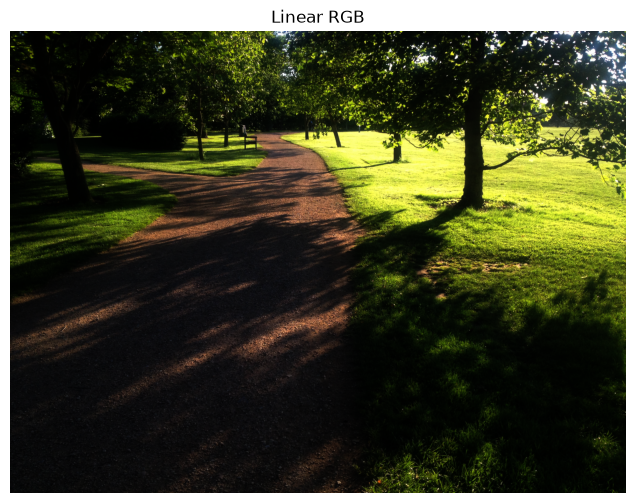

In [7]:
# TODO: display linear_rgb after clipping to [0,1].
def srgb_to_linear(rgb):
    return np.where(
        rgb <= 0.04045,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )
rgb = image_rgb.astype(np.float32) / 255.0
linear_rgb = srgb_to_linear(rgb)

plt.figure(figsize=(10, 6))
plt.imshow(np.clip(linear_rgb, 0, 1))
plt.title("Linear RGB")
plt.axis("off")
plt.show()


## 4.2 Log Chromaticity

For each pixel compute the geometric mean

$$
M=(RGB)^{1/3}.
$$

Then define

$$
\rho_R=\log\frac{R}{M},
\qquad
\rho_G=\log\frac{G}{M},
\qquad
\rho_B=\log\frac{B}{M}.
$$

Use a small $\epsilon$ for numerical stability.

Verify numerically that

$$
\rho_R+\rho_G+\rho_B\approx0.
$$


In [8]:

    # TODO:
    # 1. clamp values with eps
    # 2. compute geometric mean M
    # 3. compute rho_R, rho_G, rho_B
    # 4. stack into an H x W x 3 array
  
# TODO: verify rho[...,0] + rho[...,1] + rho[...,2] is approximately zero.

def log_chromaticity(linear_rgb, eps=1e-6):
    rgb_safe = np.clip(linear_rgb, eps, None)

    R = rgb_safe[..., 0]
    G = rgb_safe[..., 1]
    B = rgb_safe[..., 2]

    M = (R * G * B) ** (1.0 / 3.0)

    rho_R = np.log(R / M)
    rho_G = np.log(G / M)
    rho_B = np.log(B / M)

    rho = np.stack([rho_R, rho_G, rho_B], axis=-1)

    return rho
rho = log_chromaticity(linear_rgb)

rho_sum = rho[..., 0] + rho[..., 1] + rho[..., 2]

print("Maximum absolute error:", np.max(np.abs(rho_sum)))

Maximum absolute error: 1.4305115e-06



## 4.3 Project to a Two-Dimensional Chromaticity Plane

Use the orthonormal basis

$$
u_1=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-1\\
0
\end{bmatrix},
\qquad
u_2=
\frac{1}{\sqrt{6}}
\begin{bmatrix}
1\\
1\\
-2
\end{bmatrix}.
$$

Compute

$$
\chi_1=u_1^T\rho,
\qquad
\chi_2=u_2^T\rho.
$$


In [9]:

u1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
u2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)
chi1 = np.sum(rho * u1, axis=-1)
chi2 = np.sum(rho * u2, axis=-1)
# TODO: compute chi1 and chi2 for all pixels.




## 4.4 Plot Illuminated and Shadowed Pixels in Log-Chromaticity Space

Plot pixels from the two selected ROIs in $(\chi_1,\chi_2)$ coordinates.

Use different markers or colors for the illuminated and shadowed regions.

Do the two groups appear displaced primarily along a common direction?


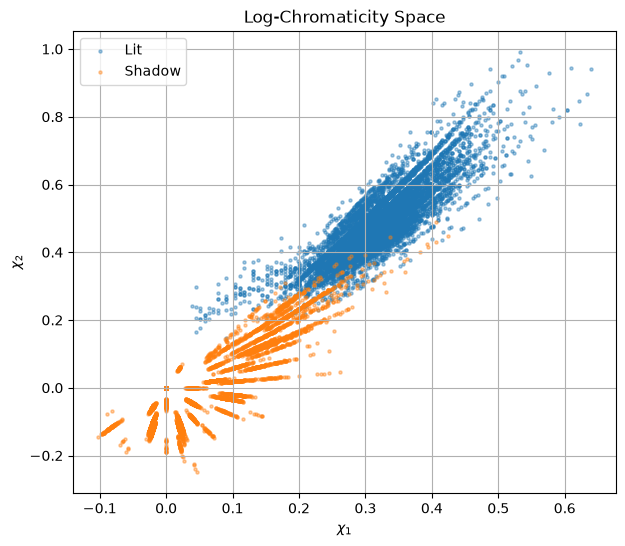

In [10]:

def roi_values(image_2d, roi):
    x1, y1, x2, y2 = roi
    return image_2d[y1:y2, x1:x2].ravel()
lit_x = roi_values(chi1, lit_roi)
lit_y = roi_values(chi2, lit_roi)

shadow_x = roi_values(chi1, shadow_roi)
shadow_y = roi_values(chi2, shadow_roi)
plt.figure(figsize=(7, 6))

plt.scatter(
    lit_x,
    lit_y,
    s=5,
    alpha=0.4,
    label="Lit"
)

plt.scatter(
    shadow_x,
    shadow_y,
    s=5,
    alpha=0.4,
    label="Shadow"
)

plt.xlabel(r"$\chi_1$")
plt.ylabel(r"$\chi_2$")
plt.title("Log-Chromaticity Space")
plt.legend()
plt.grid()
plt.show()
# TODO:
# lit_x = roi_values(chi1, lit_roi)
# lit_y = roi_values(chi2, lit_roi)
# shadow_x = roi_values(chi1, shadow_roi)
# shadow_y = roi_values(chi2, shadow_roi)
#
# plt.scatter(...)



## 4.5 Shadow-Invariant Projection

Reproduce Corke's fixed-angle example using

$$
\theta=0.7\text{ rad}.
$$

Compute

$$
I_{\text{inv}}
=
\chi_1\cos\theta
+
\chi_2\sin\theta.
$$

Normalize only for visualization.


In [12]:
# Sweep theta to find a projection angle that minimizes
# the difference between the lit and shadow ROIs.

thetas = np.linspace(0, np.pi, 181)
roi_differences = []

x1_l, y1_l, x2_l, y2_l = lit_roi
x1_s, y1_s, x2_s, y2_s = shadow_roi

for theta_test in thetas:
    inv_test = (
        chi1 * np.cos(theta_test)
        + chi2 * np.sin(theta_test)
    )

    lit_mean = inv_test[y1_l:y2_l, x1_l:x2_l].mean()
    shadow_mean = inv_test[y1_s:y2_s, x1_s:x2_s].mean()

    roi_differences.append(abs(lit_mean - shadow_mean))

best_index = np.argmin(roi_differences)
best_theta = thetas[best_index]

print("Fixed theta:", 0.7)
print("ROI-optimized theta:", best_theta)
print("Minimum ROI difference:", roi_differences[best_index])

Fixed theta: 0.7
ROI-optimized theta: 2.6354471705114375
Minimum ROI difference: 0.004055393303464688


In [18]:
invariant_best = (
    chi1 * np.cos(best_theta)
    + chi2 * np.sin(best_theta)
)

invariant_best_display = cv2.normalize(
    invariant_best,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

In [19]:

# TODO:
# invariant = chi1 * np.cos(theta) + chi2 * np.sin(theta)

# Normalize for display only:
# invariant_display = cv2.normalize(
#     invariant, None, 0, 255, cv2.NORM_MINMAX
# ).astype(np.uint8)

theta = 0.7

invariant = (
    chi1 * np.cos(theta)
    + chi2 * np.sin(theta)
)
invariant_display = cv2.normalize(
    invariant,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


Display side-by-side:

1. original RGB image,
2. ordinary grayscale image,
3. shadow-invariant image.

Then answer:

1. Which shadow boundaries became weaker?
   Several cast-shadow boundaries became weaker in the shadow-invariant image. Several cast-shadow boundaries became weaker in both shadow-invariant images. In particular, the elongated tree shadows crossing the path are much less pronounced than in the original RGB and grayscale images. The fixed theta=0.7 projection reduces many of these illumination-induced structures, while the ROI-optimized theta=2.635 further reduces the difference between the selected illuminated and shadowed road regions. However, some shadow-related structure remains in other parts of the scene.
2. Which physical or material boundaries remained?
   Several physical and material boundaries remain visible, including the boundary between the path and surrounding grass, tree trunks, and parts of the vegetation structure. These boundaries are associated more with changes in material or scene geometry than with illumination alone. The two projection angles preserve different amounts of scene structure, showing that the choice of theta affects the trade-off between shadow suppression and preservation of meaningful physical boundaries.


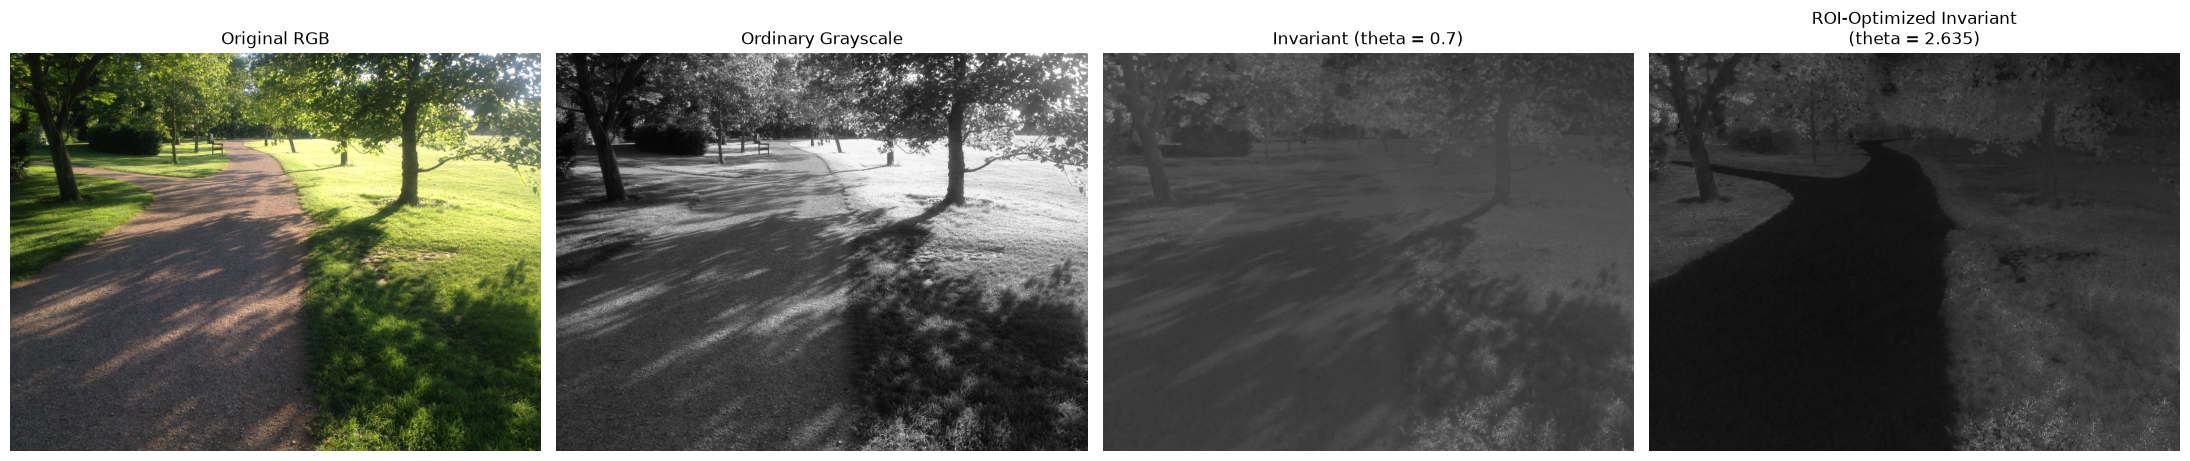

In [20]:

gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(22, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Ordinary Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(invariant_display, cmap="gray")
plt.title("Invariant (theta = 0.7)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(invariant_best_display, cmap="gray")
plt.title(f"ROI-Optimized Invariant\n(theta = {best_theta:.3f})")
plt.axis("off")

plt.tight_layout()
plt.show()
# TODO: create a 1x3 figure showing:
# original RGB
# grayscale
# invariant_display



# 5. Quantitative Evaluation

Use the same illuminated and shadowed ROIs.

For grayscale compute

$$
\Delta_{\text{gray}}
=
|\mu_{\text{lit}}-\mu_{\text{shadow}}|.
$$

For the invariant image compute

$$
\Delta_{\text{inv}}
=
|\mu_{\text{lit}}^{\text{inv}}
-
\mu_{\text{shadow}}^{\text{inv}}|.
$$

A successful representation should approximately satisfy

$$
\Delta_{\text{inv}} < \Delta_{\text{gray}}.
$$


In [21]:

def mean_scalar(image_2d, roi):
    return roi_values(image_2d, roi).mean()
gray_lit = mean_scalar(gray, lit_roi)
gray_shadow = mean_scalar(gray, shadow_roi)

# Fixed theta = 0.7
inv_lit = mean_scalar(invariant, lit_roi)
inv_shadow = mean_scalar(invariant, shadow_roi)

# ROI-optimized theta
best_lit = mean_scalar(invariant_best, lit_roi)
best_shadow = mean_scalar(invariant_best, shadow_roi)

delta_gray = abs(gray_lit - gray_shadow)
delta_inv = abs(inv_lit - inv_shadow)
delta_inv_best = abs(best_lit - best_shadow)

print("Delta gray:", delta_gray)
print("Delta invariant (theta = 0.7):", delta_inv)
print("Delta ROI-optimized invariant:", delta_inv_best)
# TODO:
# delta_gray = ...
# delta_inv = ...
# print(...)


Delta gray: 92.8766
Delta invariant (theta = 0.7): 0.5489903732705775
Delta ROI-optimized invariant: 0.004055393303464688



## 5.1 Compare Edges

Use OpenCV Canny on:

1. the ordinary grayscale image,
2. the normalized shadow-invariant image.

Look for one shadow edge and one real material/object edge.

The desired behavior is:

- weaker response at the shadow boundary,
- preservation of real scene boundaries.


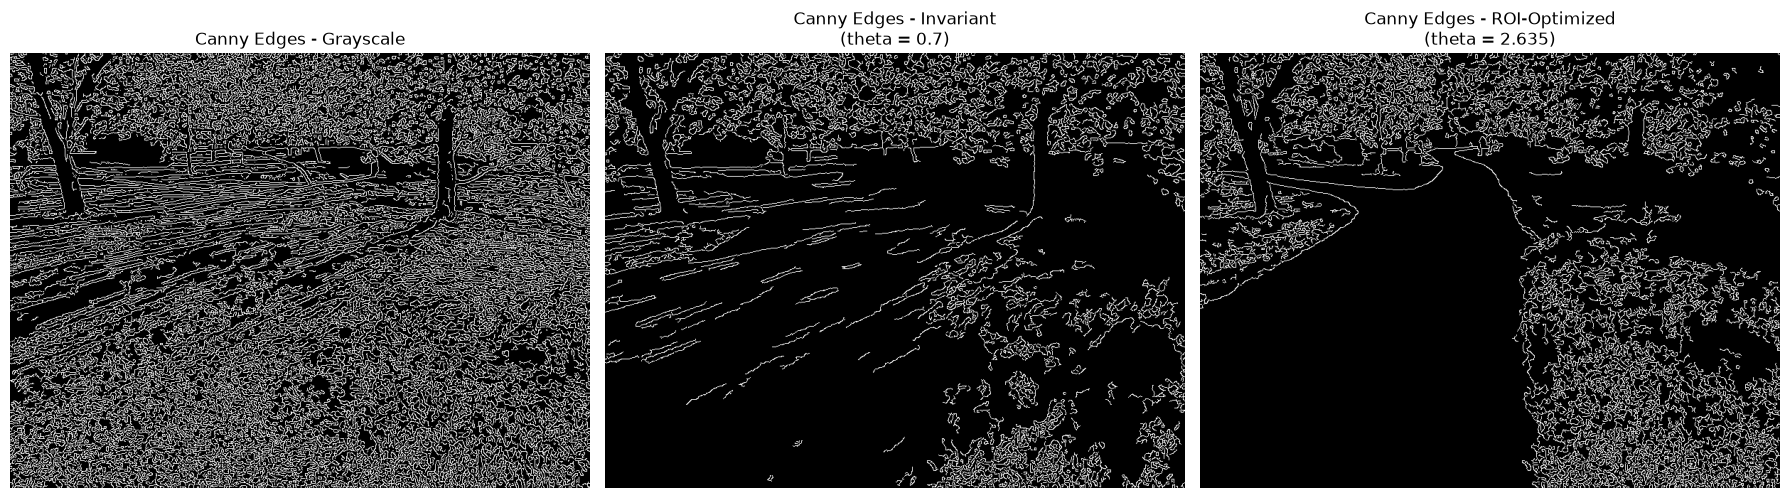

In [24]:

# TODO: tune thresholds if needed.
# TODO:
# edges_inv = cv2.Canny(invariant_display, 50, 150)

# TODO: display both edge maps.
# Downsample to quarter resolution
gray_small = cv2.resize(
    gray,
    None,
    fx=0.25,
    fy=0.25,
    interpolation=cv2.INTER_AREA
)

inv_small = cv2.resize(
    invariant_display,
    None,
    fx=0.25,
    fy=0.25,
    interpolation=cv2.INTER_AREA
)

inv_best_small = cv2.resize(
    invariant_best_display,
    None,
    fx=0.25,
    fy=0.25,
    interpolation=cv2.INTER_AREA
)

# Gaussian blur to suppress fine texture
gray_blur = cv2.GaussianBlur(gray_small, (5, 5), 0)
inv_blur = cv2.GaussianBlur(inv_small, (5, 5), 0)
inv_best_blur = cv2.GaussianBlur(inv_best_small, (5, 5), 0)

# Same Canny thresholds for all three
edges_gray = cv2.Canny(gray_blur, 10, 30)
edges_inv = cv2.Canny(inv_blur, 10, 30)
edges_inv_best = cv2.Canny(inv_best_blur, 10, 30)

# Plot
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(edges_gray, cmap="gray")
plt.title("Canny Edges - Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges_inv, cmap="gray")
plt.title("Canny Edges - Invariant\n(theta = 0.7)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges_inv_best, cmap="gray")
plt.title(
    f"Canny Edges - ROI-Optimized\n(theta = {best_theta:.3f})"
)
plt.axis("off")

plt.tight_layout()
plt.show()

Note: Compared with the grayscale edge map, both shadow-invariant representations suppress many illumination-induced edges. The grayscale image contains dense edges caused by shadows and fine texture, while the fixed projection at theta=0.7 removes much of this structure. The ROI-optimized projection at theta=2.635 further suppresses shadow-related edges within the selected road region while preserving several physical boundaries, including the road boundary, tree trunks, and vegetation structure. However, because the optimized angle was selected using specific road ROIs, it should not be interpreted as globally optimal for the entire scene.


# 6. Port the Final Pipeline to PyTorch and Kornia

The goal of this section is to express the same classical computer-vision pipeline as tensor operations.

This allows:

- batching,
- GPU execution,
- automatic differentiation.

Kornia provides differentiable computer-vision operators that integrate directly with PyTorch computation graphs.


In [25]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rgb_t = (
    torch.from_numpy(image_rgb)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    .div(255.0)
    .to(device)
)

print("Tensor shape:", rgb_t.shape)
print("Device:", rgb_t.device)


Tensor shape: torch.Size([1, 3, 2448, 3264])
Device: cuda:0



## 6.1 Linear RGB with Kornia

Use:

```python
kornia.color.rgb_to_linear_rgb(...)
```

Then reproduce the same log-chromaticity and projection equations using PyTorch tensor operations.


In [15]:

    # Expected input shape: B x 3 x H x W
    #
    # TODO:
    # 1. clamp channels with eps
    # 2. compute geometric mean
    # 3. compute log chromaticities
    # 4. project using u1 and u2
    # 5. compute invariant = chi1*cos(theta) + chi2*sin(theta)
    #
    # Return shape: B x H x W

linear_t = kornia.color.rgb_to_linear_rgb(rgb_t)

def shadow_invariant_torch(linear_rgb_t, theta=0.7, eps=1e-6):
    # Expected input shape: B x 3 x H x W

    # 1. Clamp for numerical stability
    rgb_safe = torch.clamp(linear_rgb_t, min=eps)

    # 2. Extract RGB channels
    R = rgb_safe[:, 0]
    G = rgb_safe[:, 1]
    B = rgb_safe[:, 2]

    # 3. Geometric mean
    M = (R * G * B).pow(1.0 / 3.0)

    # 4. Log chromaticities
    rho_R = torch.log(R / M)
    rho_G = torch.log(G / M)
    rho_B = torch.log(B / M)

    rho = torch.stack(
        [rho_R, rho_G, rho_B],
        dim=1
    )

    # 5. Orthonormal basis
    u1 = torch.tensor(
        [1.0, -1.0, 0.0],
        dtype=linear_rgb_t.dtype,
        device=linear_rgb_t.device
    ) / np.sqrt(2.0)

    u2 = torch.tensor(
        [1.0, 1.0, -2.0],
        dtype=linear_rgb_t.dtype,
        device=linear_rgb_t.device
    ) / np.sqrt(6.0)

    # Project to 2-D chromaticity plane
    chi1 = (
        rho * u1.view(1, 3, 1, 1)
    ).sum(dim=1)

    chi2 = (
        rho * u2.view(1, 3, 1, 1)
    ).sum(dim=1)

    # Final 1-D projection
    theta_t = torch.tensor(
        theta,
        dtype=linear_rgb_t.dtype,
        device=linear_rgb_t.device
    )

    invariant = (
        chi1 * torch.cos(theta_t)
        + chi2 * torch.sin(theta_t)
    )

    return invariant


invariant_t = shadow_invariant_torch(
    linear_t,
    theta=0.7
)

print("Invariant shape:", invariant_t.shape)
print("Invariant device:", invariant_t.device)


Invariant shape: torch.Size([1, 2448, 3264])
Invariant device: cuda:0



## 6.2 Compare NumPy/OpenCV and PyTorch/Kornia Results

Compute

$$
\mathrm{MAE}
=
\frac{1}{N}
\sum_i
|I_i^{\mathrm{NumPy}}
-
I_i^{\mathrm{PyTorch}}|.
$$

The two implementations should be numerically very similar.


In [39]:

# TODO:
# invariant_t_np = invariant_t.squeeze(0).detach().cpu().numpy()
# mae = np.mean(np.abs(invariant - invariant_t_np))
# print("MAE:", mae)
invariant_t_np = (
    invariant_t
    .squeeze(0)
    .detach()
    .cpu()
    .numpy()
)

mae = np.mean(
    np.abs(invariant - invariant_t_np)
)

print("MAE:", mae)

MAE: 8.12315356725986e-08



## 6.3 Optional GPU Batch Experiment

If CUDA is available, process a batch of 32 identical images.

Report:

- execution device,
- batch shape,
- elapsed time.

No GPU speedup is required for full credit.


In [ ]:
NOte:Increasing the batch size allows more images to be processed in parallel on the GPU, but it also increases GPU memory usage. On the available GPU, a batch size of 8 could be executed successfully, while larger batches may exceed the available memory.

In [16]:

if torch.cuda.is_available():
    batch = rgb_t.repeat(8, 1, 1, 1)
    batch_linear = kornia.color.rgb_to_linear_rgb(batch)

    torch.cuda.synchronize()
    t0 = time.perf_counter()

    # TODO:
    # batch_inv = shadow_invariant_torch(batch_linear, theta=0.7)
    batch_inv = shadow_invariant_torch(
    batch_linear,
    theta=0.7
)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    print("Batch shape:", batch.shape)
    print("Elapsed:", elapsed)
else:
    print("CUDA not available; GPU timing is optional.")


Batch shape: torch.Size([8, 3, 2448, 3264])
Elapsed: 0.06124134700075956



# 7. Discussion

Return to the autonomous-driving example at the beginning.

Answer in approximately one paragraph:

1. Why does the shadow generate strong image structure even though there is no new physical object?
2. What quantity does the invariant projection attempt to suppress?
3. Why can preserving reflectance-related edges while suppressing illumination edges help perception?
4. Why would this classical method still be insufficient by itself for autonomous driving?

Consider geometry, depth, semantics, temporal reasoning, learned representations, and sensor fusion.


A shadow can create strong image structure because it produces a sharp change in illumination, causing large changes in pixel intensity even though the underlying physical surface has not changed. The invariant projection attempts to suppress this illumination-related variation by projecting the log-chromaticity representation in a direction that reduces changes caused by lighting. This is useful because it can weaken false edges produced by shadows while preserving edges that are more closely related to real reflectance or material changes, which can help a perception system distinguish physical boundaries from lighting effects. However, this classical method is not sufficient by itself for autonomous driving because real driving scenes involve complex geometry, depth changes, object semantics, motion over time, nonuniform illumination, reflections, and weather. A robust autonomous-driving system therefore also needs depth sensing, temporal reasoning, learned visual representations, object-level semantics, and sensor fusion with modalities such as LiDAR or radar. In our results, many cast-shadow edges were reduced, but some real scene boundaries were also weakened, showing that the method is useful but not perfectly selective.
The experiment also showed that the projection angle influences the balance between suppressing illumination-induced edges and preserving meaningful scene structure. An ROI-optimized angle reduced shadow differences more strongly in the selected road region, but such an angle may not generalize globally across the scene.


# Deliverables

Your notebook must execute from beginning to end, and you must submit it with all outputs saved.

Required outputs:

- two blackbody curves,
- RGB/HSV/Lab comparison,
- log-chromaticity scatter plot,
- shadow-invariant image,
- quantitative shadow comparison,
- OpenCV edge comparison,
- PyTorch/Kornia implementation,
- short final discussion.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.

The per-component points are on the assignment page.



# References

1. Peter Corke, *Robotics, Vision & Control: Fundamental Algorithms in Python*, 3rd ed., Springer, Chapter 10. [Download the chapter (PDF)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)
2. G. D. Finlayson, S. D. Hordley, and M. S. Drew, "Removing Shadows from Images," ECCV, 2002.
3. G. D. Finlayson, M. S. Drew, and C. Lu, "Intrinsic Images by Entropy Minimization," ECCV, 2004.
4. G. D. Finlayson, S. D. Hordley, C. Lu, and M. S. Drew, "On the Removal of Shadows from Images," IEEE TPAMI, 2006.
5. Kornia documentation: https://kornia.readthedocs.io/
6. OpenCV documentation: https://docs.opencv.org/
